<a href="https://colab.research.google.com/github/derekwilsonyt/HandsOnDeepLearning/blob/main/Derek_Wilson_HODL_SP26_HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#15.773 Homework 2 (Spring 2026): Natural Langugage Processing

-----
**IMPORTANT: Choose a T-4 GPU with High-RAM or an A100 GPU**
-----

Install the `keras-hub` package so that we can access pretrained Transformer models.

In [1]:
!pip install --upgrade keras-hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 92.8 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.10.0
    Uninstalling keras-3.10.0:
      Successfully uninstalled keras-3.10.0
  Attempting uninstall: keras-hub
    Found existing installation: keras-hub 0.21.1
    Uninstalling keras-hub-0.21.1:
      Successfully uninstalled keras-hub-0.21.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.21.1 requires keras-hub==0.21.1, but you have keras-hub 0.26.0 which is incompatible.


In [2]:
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import keras

keras.utils.set_random_seed(42)

# Introduction

This homework assignment will ask you to build models using (1) the Bag-of-Words approach and (2) and by fine-tuning BERT.

We will work with a famous dataset in natural langauge processing called **20 Newsgroup**,  which consists of posts from an online forum under certain topics such as politics, religion, sports...etc. As the name suggests, there are a total of 20 topics in this dataset. The 20 Newsgroup dataset is a popular benchmark for text classification algorithms.

The entire dataset is quite large. To ensure training takes a reasonable amount of time, we will only choose 6 out of the 20 topics, including topics like religion, space (astronomy) and medicine.

In [4]:
from sklearn.datasets import fetch_20newsgroups

newsgroups_train = fetch_20newsgroups(subset='train', categories = ['alt.atheism', 'talk.religion.misc', 'comp.graphics', 'sci.space', 'sci.med', 'rec.autos'])
newsgroups_test = fetch_20newsgroups(subset='test', categories = ['alt.atheism', 'talk.religion.misc', 'comp.graphics', 'sci.space', 'sci.med', 'rec.autos'])

train_df = pd.DataFrame({'text': newsgroups_train.data, 'label': newsgroups_train.target})
test_df = pd.DataFrame({'text': newsgroups_test.data, 'label': newsgroups_test.target})

print(f"""
Train samples: {train_df.shape[0]}
Test samples: {test_df.shape[0]}
""")

train_df.head(10)


Train samples: 3222
Test samples: 2145



,text,label
0,From: boylan@pi.eai.iastate.edu (Terran Boylan...,1
1,From: I3150101@dbstu1.rz.tu-bs.de (Benedikt Ro...,0
2,From: snichols@adobe.com (Sherri Nichols)\nSub...,3
3,From: johnm@spudge.lonestar.org (John Munsch)\...,1
4,From: Nanci Ann Miller <nm0w+@andrew.cmu.edu>\...,0
5,From: nsmca@aurora.alaska.edu\nSubject: 30826\...,4
6,From: geb@cs.pitt.edu (Gordon Banks)\nSubject:...,3
7,From: higgins@fnalf.fnal.gov (Bill Higgins-- B...,4
8,From: mmm@cup.portal.com (Mark Robert Thorson)...,3
9,From: daniel@lclark.edu (Daniel Snodgrass)\nSu...,1


The distribution of labels across these 6 classes is fairly balanced.



In [5]:
train_df['label'].value_counts() / train_df.shape[0]

,count
label,
2,0.184358
3,0.184358
4,0.184047
1,0.181254
0,0.148976
5,0.117008


Let's convert our dependent variable into a 1-hot-encoded vector.

In [6]:
# Let's turn the target into a dummy vector
y_train = pd.get_dummies(train_df['label'], dtype="int").to_numpy()
y_test = pd.get_dummies(test_df['label'], dtype="int").to_numpy()

y_train[:10]

array([[0, 1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0],
       [0, 1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0],
       [0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 1, 0],
       [0, 0, 0, 1, 0, 0],
       [0, 1, 0, 0, 0, 0]])

# Problem 1: Bag-of-Words (BoW) Model [50 Points]

In this problem, we will build a bag-of-words model using the text vectorization capabilities of Keras. We will then change some of the parameters of this vectorization process and see how it changes the performance.



## Part (a): Build a Base Model [15 Points]

**Text Vectorization**

Please fill in the code in the following cell. We would like to create a text vectorization layer which uses:

* Maximum of 2000 tokens.
* Unigrams
* Outputs a multi-hot encoded BoW encoding
* Converts text to lower case and strips punctuation

In [7]:
# Set the maximum number of tokens (which is the size of the vocabulary) to 2000
max_tokens = 2000

# Configure the text vectorization layer
text_vectorization = keras.layers.TextVectorization(
     max_tokens=max_tokens,
     ngrams=1,
     output_mode='multi_hot',
)

# Let's adapt the Text Vectorization layer using the training corpus
text_vectorization.adapt(train_df['text'])

# We vectorize our input with the adapted Text Vectorization layer
X_train = text_vectorization(train_df['text'])
X_test = text_vectorization(test_df['text'])

pd.DataFrame(X_train, columns = text_vectorization.get_vocabulary())

,[UNK],the,of,to,a,and,in,is,i,that,...,loving,learning,jaegerbuphybuedu,hour,helps,glutamate,finding,delta,careful,bother
0,1,1,1,1,1,1,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,1,1,1,1,1,1,1,1,1,1,...,0,0,1,0,0,0,0,0,0,0
2,1,1,0,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3217,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3218,1,1,1,1,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3219,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3220,1,1,1,1,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0


In the following cell, please build a simple Neural Network with a single hidden layer of 128 neurons with ReLu activation. Be sure to specify the shape of the input correctly and use the appropriate activation function for the output. Your model should have 256902 parameters. The code for compiling has been written for you already.

In [8]:
### YOUR CODE BELOW ###
inputs = keras.layers.Input(shape=(max_tokens, ))
x = keras.layers.Dense(128, activation="relu")(inputs)

# ....

outputs = keras.layers.Dense(6, activation="softmax")(x)

### YOUR CODE ABOVE ###

bow_model = keras.Model(inputs, outputs)
bow_model.summary()

bow_model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy']
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       256,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 256,902 (1003.52 KB)

 Trainable params: 256,902 (1003.52 KB)

 Non-trainable params: 0 (0.00 B)

A theme that we will be investigating in this homework is the **impact of the number of training examples on the different models**. As a result, in addition to training the model on all 3000+ training examples, we will also test how our model performs with only 200 examples.

The code below shows a fitting process in which we first fit model `bow_model` to the first 200 examples from the training set `(X_train[:200], y_train[:200]`). We print the accuracy of the model on the test set. Then, we run the training procedure for another 20 epochs, this time with the full data set `(X_train, y_train`). You just need to run the cell.

In [9]:
# Fit model on the training data with 20 epochs and batch size of 32
bow_model.fit(
    x=X_train[:200], y=y_train[:200],
    epochs=20, batch_size=32,
    verbose=1,
)

print(f"*** Test accuracy with 200 examples:{bow_model.evaluate(x=X_test, y=y_test)[1]:.2%} ***")


# Fit model on the training data with 20 epochs and batch size of 32
bow_model.fit(
    x=X_train, y=y_train,
    epochs=20, batch_size=32,
    verbose=1,
)

print(f"*** Test accuracy with ALL examples:{bow_model.evaluate(x=X_test, y=y_test)[1]:.2%} ***")

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 163ms/step - accuracy: 0.3350 - loss: 1.7122
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9150 - loss: 1.1151 
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9800 - loss: 0.7382 
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9900 - loss: 0.4669 
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.2914 
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.1830 
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.1179 
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0791 
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0557 
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0412 
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0318 
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0254 


**<font color='red'>Please Answer Below</font>**

BoW Base Model
* Test accuracy with 200 Examples: **62.33%**
* Test accuracy with All Examples: **82.8%**

***Briefly comment on if the accuracy numbers are surprising or unsurprising.***

It's not suprising that more examples resulted in better accuracy. I'm slightly suprised that such a small number of examples (200) resulted in a relatively strong accuracy of 62% vs random guessing that would have resulted in around 16.6% accuracy. The fact that training the model with 3000+ examples increased the accuracy by an additional 20% (to 82.8%) is significant and shows that there are diminishing returns to additional data, but that we haven't yet started overfitting. Each additional percentage accuracy requires more data and training than the previous percentage, which is expected.

***What is the baseline performance by predicting the most frequent class?***

Baseline performance predicting the most frequent class would have been 18.4% accuracy.


## Part (b): Explore Hyperparameters [35 Points]

Now, let us try changing some of the hyperparameters in the text vectorization process.

* Use bigrams instead of unigrams.
* Increase the maximum number of tokens from 2000 to 5000
* Use count encoding instead of multi-hot encoding

For each of the above modifications,
* modify the code cell below (feel free to copy-paste the code from above)
* run the code cell and
* report the test accuracy.

<font color='red'>Note that you should make each change independent of the other two changes. When you are done, you should have 3 versions of the code cell below.</font>




In [16]:
#Use bigrams instead of unigrams
max_tokens = 2000

text_vectorization = keras.layers.TextVectorization(
    max_tokens=max_tokens,
     ngrams=2,
     output_mode='multi_hot'
)

text_vectorization.adapt(train_df['text'])

X_train = text_vectorization(train_df['text'])
X_test = text_vectorization(test_df['text'])

### YOUR CODE BELOW ###
inputs = keras.layers.Input(shape=(X_train.shape[1],))
x = keras.layers.Dense(128, activation="relu")(inputs)

# ....

outputs = keras.layers.Dense(6, activation="softmax")(x)
### YOUR CODE ABOVE ###

bow_model = keras.Model(inputs, outputs)
bow_model.summary()

bow_model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy']
)

bow_model.fit(
    x=X_train[:200], y=y_train[:200],
    epochs=20, batch_size=32,
    verbose=1,
)
print("\n*** Test accuracy with 200 Examples: %.4f ***\n" % bow_model.evaluate(x=X_test, y=y_test)[1])

bow_model.fit(
    x=X_train, y=y_train,
    epochs=20, batch_size=32,
    verbose=1,
)
print("\n*** Test accuracy with All Examples % .4f ***\n" % bow_model.evaluate(x=X_test, y=y_test)[1])

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 2000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       256,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 256,902 (1003.52 KB)

 Trainable params: 256,902 (1003.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.1850 - loss: 1.7647
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9100 - loss: 1.1022 
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.7109 
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.4370 
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.2649 
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.1608 
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.1010 
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0669 
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0471 
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0350 
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0273 
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0221 


In [17]:
#Increase the maximum number of tokens from 2000 to 5000
max_tokens = 5000

text_vectorization = keras.layers.TextVectorization(
    max_tokens=max_tokens,
     ngrams=1,
     output_mode='multi_hot'
)

text_vectorization.adapt(train_df['text'])

X_train = text_vectorization(train_df['text'])
X_test = text_vectorization(test_df['text'])

### YOUR CODE BELOW ###
inputs = keras.layers.Input(shape=(X_train.shape[1],))
x = keras.layers.Dense(128, activation="relu")(inputs)

# ....

outputs = keras.layers.Dense(6, activation="softmax")(x)
### YOUR CODE ABOVE ###

bow_model = keras.Model(inputs, outputs)
bow_model.summary()

bow_model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy']
)

bow_model.fit(
    x=X_train[:200], y=y_train[:200],
    epochs=20, batch_size=32,
    verbose=1,
)
print("\n*** Test accuracy with 200 Examples: %.4f ***\n" % bow_model.evaluate(x=X_test, y=y_test)[1])

bow_model.fit(
    x=X_train, y=y_train,
    epochs=20, batch_size=32,
    verbose=1,
)
print("\n*** Test accuracy with All Examples % .4f ***\n" % bow_model.evaluate(x=X_test, y=y_test)[1])

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 5000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 640,902 (2.44 MB)

 Trainable params: 640,902 (2.44 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.2250 - loss: 1.7531
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9700 - loss: 0.9800 
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9900 - loss: 0.5415 
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.2812 
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.1468 
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0813 
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0487 
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0318 
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0225 
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0170 
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0135 
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0111 


In [18]:
#Use count encoding instead of multi-hot encoding
max_tokens = 2000

text_vectorization = keras.layers.TextVectorization(
    max_tokens=max_tokens,
     ngrams=1,
     output_mode='count'
)

text_vectorization.adapt(train_df['text'])

X_train = text_vectorization(train_df['text'])
X_test = text_vectorization(test_df['text'])

### YOUR CODE BELOW ###
inputs = keras.layers.Input(shape=(X_train.shape[1],))
x = keras.layers.Dense(128, activation="relu")(inputs)

# ....

outputs = keras.layers.Dense(6, activation="softmax")(x)
### YOUR CODE ABOVE ###

bow_model = keras.Model(inputs, outputs)
bow_model.summary()

bow_model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy']
)

bow_model.fit(
    x=X_train[:200], y=y_train[:200],
    epochs=20, batch_size=32,
    verbose=1,
)
print("\n*** Test accuracy with 200 Examples: %.4f ***\n" % bow_model.evaluate(x=X_test, y=y_test)[1])

bow_model.fit(
    x=X_train, y=y_train,
    epochs=20, batch_size=32,
    verbose=1,
)
print("\n*** Test accuracy with All Examples % .4f ***\n" % bow_model.evaluate(x=X_test, y=y_test)[1])

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 2000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       256,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 256,902 (1003.52 KB)

 Trainable params: 256,902 (1003.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - accuracy: 0.2350 - loss: 2.1318
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5800 - loss: 1.3029 
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9100 - loss: 0.8498 
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9750 - loss: 0.5934 
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.4258 
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.3119 
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.2264 
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.1663 
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.1241 
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0943 
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0726 
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0566 


**<font color='red'>Please Answer Below</font>**

Fill in the blanks with the test accuracies you obtained from re-running Problem 1(a)'s code with the relevant modifications.

For each of the 3 modifications, briefly comment on why one might expect such a change to be beneficial. Using the numbers above, comment on whether it improved, hurt or didn't affect the model's performance.

* Bigrams instead of unigrams
  * 200 Training Examples: **57.26%**
  * All Training Examples: **78.23%**
  * Comment: **Using bigrams resulted in slightly worse accuracy than unigrams. Bigrams can capture short phrases that unigrams miss, so I would have expected an improvement. The results could be explained because with max 2000 tokens, including bigrams uses up vocabulary slots, potentially crowding out informative unigrams. Performance dropped to 78.23% vs 82.8%, suggesting the added phrase features werent worth the lost unigram coverage under the vocab cap.**
* Increasing max_tokens to 5000.
  * 200 Training Examples: **66.53%**
  * All Training Examples: **87.37%**
  * Comment: **Increasing the max tokens from 2000 to 5000 improved the model performance. Increasing max_tokens allows the model to keep a larger vocab of topic-specific terms, which can reduce information loss and improve classification. Here it improved accuracy (87.37% vs 82.8%), indicating that the additional tokens added useful signal rather than noise. More tokens also increases model capacity since the input dimensionality grows and there are more total trainable parameters.**
* Count instead of multi-hot
  * 200 Training Examples: **62.66%**
  * All Training Examples: **83.12%**
  * Comment: **Switching from multi-hot to counts had little effect (83.12% vs 82.8%). Multi-hot captures the presence of words and the results suggest that this is sufficient in this case. Count encoding would preserve frequency information and could help if repeated use of certain terms is informative, but it doesn't seem that it made any difference in this case.**

# Problem 2: BERT Transformer Model [50 Points]

In this problem, you will demonstrate how using a pre-trained model like [Bert](https://en.wikipedia.org/wiki/BERT_(language_model)) can yield high accuracy with as little as 200 examples.

## Setup

### Get access to Keras Hub pretrained models

Follow these instructions before continuing with the Colab. This is a one-time thing and will be useful in future colabs as well.

* Go to [kaggle.com](https://kaggle.com) and create an account.
* Go to the **Account** tab of your Kaggle user profile and select **Create New Token**. This will trigger the download of a `kaggle.json` file containing your Kaggle username and Kaggle API key.
* Open this file using a text editor.
* In Colab, select **Secrets** (the key image) in the left pane.  
* Click "Add new secret"
* Copy your Kaggle username from the text editor and store it under the name `KAGGLE_USERNAME`.  
* Click "Add new secret"
* Copy your Kaggle API key from the text editor and store it under the name `KAGGLE_KEY`.
* Toggle "Notebook Access" to ON for both.

When you are done, it should look something like this:



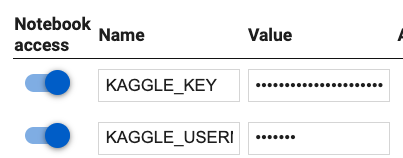

In [19]:
import keras_hub

We will download Bert from the Keras Hub model repository. This will take a minute or two the first time you do it.

In [20]:
bert = keras_hub.models.BertClassifier.from_preset(
    "bert_base_en_uncased",
    activation="softmax",
    num_classes=6
)

Take a look at Bert's architecture.

In [21]:
bert.summary()

Preprocessor: "bert_text_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ bert_tokenizer (BertTokenizer)                                │                       Vocab size: 30,522 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "bert_text_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ segment_ids (InputLayer)      │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bert_backbone (BertBackbone)  │ [(None, 768), (None,      │     109,482,240 │ padding_mask[0][0],        │
│                               │ None, 768)]               │                 │ segment_ids[0][0],         │
│                               │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ classifier_dropout (Dropout)  │ (None, 768)               │               0 │ bert_backbone[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 6)                 │           4,614 │ classifier_dropout[0][0]   │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 109,486,854 (417.66 MB)

 Trainable params: 109,486,854 (417.66 MB)

 Non-trainable params: 0 (0.00 B)

109 million parameters!!

In lecture we showed how to finetune this model end-to-end. Here, we show a different way to use BERT: we will take the BERT backbone, run our data through it and get the embedding for the CLS token for each data point, and then use that as the input for our own, little MLP.

Here's the backbone.

In [22]:
bert.backbone.summary()

Model: "bert_backbone"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ token_ids           │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_embedding     │ (None, None, 768) │ 23,440,896 │ token_ids[0][0]   │
│ (ReversibleEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ segment_ids         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ position_embedding  │ (None, None, 768) │    393,216 │ token_embedding[… │
│ (PositionEmbedding) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ segment_embedding   │ (None, None, 768) │      1,536 │ segment_ids[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embeddings_add      │ (None, None, 768) │          0 │ token_embedding[… │
│ (Add)               │                   │            │ position_embeddi… │
│                     │                   │            │ segment_embeddin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embeddings_layer_n… │ (None, None, 768) │      1,536 │ embeddings_add[0… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embeddings_dropout  │ (None, None, 768) │          0 │ embeddings_layer… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ padding_mask        │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_0 │ (None, None, 768) │  7,087,872 │ embeddings_dropo… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_1 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_2 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_3 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_4 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_5 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_6 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 109,482,240 (417.64 MB)

 Trainable params: 109,482,240 (417.64 MB)

 Non-trainable params: 0 (0.00 B)

Notice that what comes out of the backbone is a 768-long vector. This is the embedding of the CLS token.

This will be the input to our MLP.

## Run datasets through the BERT backbone

Step 1: We need to run our data through the BERT backbone and get the embedding for the CLS token for each data point.

The code cell below does this for the training dataset.

In [23]:
tokenized_input = bert.preprocessor(train_df.text)
bert_output = bert.backbone.predict(tokenized_input)['sequence_output'][:, 0, :]

101/101 ━━━━━━━━━━━━━━━━━━━━ 24s 173ms/step


Your turn: Do what we did above, for the test set.

In [24]:
test_tokenized_input = bert.preprocessor(test_df.text)
test_bert_output = bert.backbone.predict(test_tokenized_input)['sequence_output'][:, 0, :]

68/68 ━━━━━━━━━━━━━━━━━━━━ 15s 215ms/step


## Finetune on 200 examples

Define a neural network with 2 dense layers of 128 neurons each using a ReLU activation. Each dense layer should be followed by a Dropout layer with probability of 0.1.

In [26]:
### YOUR CODE BELOW ###

input = keras.Input(shape=(768,))

h1 = keras.layers.Dense(128, activation="relu")(input)
d1 = keras.layers.Dropout(0.1)(h1)
h2 = keras.layers.Dense(128, activation="relu")(d1)
d2 = keras.layers.Dropout(0.1)(h2)

output = keras.layers.Dense(6, activation="softmax")(d2)

### YOUR CODE ABOVE ###

# Model
bert_finetuned = keras.Model(input, output)

In [27]:
bert_finetuned.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,718 (452.02 KB)

 Trainable params: 115,718 (452.02 KB)

 Non-trainable params: 0 (0.00 B)

**How many parameters does your model have: ________?**

*Answer: 115,718 parameters*

Let's compile and train it.

In [28]:
bert_finetuned.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

bert_finetuned.fit(x=bert_output[:200],
                   y=y_train[:200],
                   epochs=20,
                   batch_size=32,verbose=1,
)

accuracy_200 = bert_finetuned.evaluate(x=test_bert_output, y=y_test)[1]
print(f"*** Test accuracy with 200 Examples: {accuracy_200:.2%} ***")

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 243ms/step - accuracy: 0.2450 - loss: 1.7737
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4450 - loss: 1.5612 
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5400 - loss: 1.3629 
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6500 - loss: 1.1747 
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7700 - loss: 0.9564 
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7700 - loss: 0.8309 
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7950 - loss: 0.6825 
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8800 - loss: 0.5191 
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8700 - loss: 0.4579 
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9050 - loss: 0.3747 
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9400 - loss: 0.3035 
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9450 - loss: 0.2508 


## Fine-tune on ALL examples

Your turn: Compile and train the model on ALL examples. Use the same batch size and number of epochs as above.

In [29]:
## YOUR CODE BELOW ##

bert_finetuned.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

bert_finetuned.fit(x=bert_output,
                   y=y_train,
                   epochs=20,
                   batch_size=32,verbose=1,
)

## YOUR CODE ABOVE ##


accuracy_ALL = bert_finetuned.evaluate(x=test_bert_output, y=y_test)[1]
print(f"*** Test accuracy with ALL Examples: {accuracy_ALL:.2%} ***")

Epoch 1/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8153 - loss: 0.5141
Epoch 2/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8544 - loss: 0.3895
Epoch 3/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8684 - loss: 0.3460
Epoch 4/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8929 - loss: 0.2892
Epoch 5/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8998 - loss: 0.2706
Epoch 6/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9125 - loss: 0.2436
Epoch 7/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9162 - loss: 0.2267
Epoch 8/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9233 - loss: 0.1995
Epoch 9/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9382 - loss: 0.1657
Epoch 10/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9370 - loss: 0.1613
Epoch 11/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9460 - loss: 0.1434
Epoch 12/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/ste

<font color='red'>**Please Answer Below**</font>

Fill in the table below with the accuracies from above.

The base BoW Model:
* Test accuracy with 200 Examples: **62.33%**
* Test accuracy with All Examples: **82.8%**


BERT Model Accuracy
* Test accuracy with 200 Examples: **70.96%**
* Test accuracy with All Examples: **79.81%**


Comment on the performance of the BERT-based model relative to the BoW model.

When using a small number of examples (200), the BERT-based model performed significantly better than BoW (70.96% vs 62.33%). This suggests that the pre training from BERT added significant value, especially when given a small amount of examples to fine tune with.

BUT, when all examples (3000+) were used, the BERT model performed slightly worse than the BoW model. This could be explained because in this setup we freeze the BERT backbone and train only a small MLP on CLS embeddings, so the model cant adapt BERTs internal representations to the dataset. A full end-to-end fine-tuning would potentially help close the gap. I'm also curious if the smaller input size of 768 with BERT vs 2000 with BoW, contributed to lower accuracy with BERT since there were fewer total trainable parameters.
